<img src="https://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

# Python for Finance (2nd ed.)

**Mastering Data-Driven Finance**

&copy; Dr. Yves J. Hilpisch | The Python Quants GmbH

<img src="https://hilpisch.com/images/py4fi_2nd_shadow.png" width="300px" align="left">

# Input-Output Operations

## Basic I/O with Python

### Writing Objects to Disk
For later use, for documentation, or for sharing with others, one might want to
store Python objects on disk. One option is to use the `pickle` module.

This
module can serialize the majority of Python objects.
* serialization refers to the
conversion of an object (hierarchy) to a byte stream;
* deserialization is the
opposite operation.

In [1]:
from pylab import plt, mpl
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'
# %config InlineBackend.figure_format = 'svg'

In [2]:
import pickle
import numpy as np
from random import gauss

In [3]:
import warnings
warnings.simplefilter('ignore')

In [4]:
a = [gauss(1.5, 2) for i in range(1000000)]

In [5]:
import os
# adjust to path of your choice
path = '/root/notebook/tmp/ch09/'  # raises FNF
os.makedirs(path, exist_ok=True)

In [6]:
pkl_file = open(path + 'data.pkl', 'wb')

In [7]:
%time pickle.dump(a, pkl_file)  

CPU times: user 26.4 ms, sys: 4 ms, total: 30.4 ms
Wall time: 30 ms


In [8]:
pkl_file.close()  

In [9]:
ll $path*

-rw-r--r--. 1 root 9003247 Jan  6 15:39 /root/notebook/tmp/ch09/data.pkl


In [10]:
pkl_file = open(path + 'data.pkl', 'rb')

In [11]:
%time b = pickle.load(pkl_file)

CPU times: user 35 ms, sys: 16.5 ms, total: 51.5 ms
Wall time: 52.3 ms


In [12]:
a[:3]

[0.6035227758028878, 1.187875273032109, -1.018633535131786]

In [13]:
b[:3]

[0.6035227758028878, 1.187875273032109, -1.018633535131786]

In [14]:
# Converting a and b to ndarray objects, np.allclose() verifies that both
# contain the same data (numbers)
np.allclose(np.array(a), np.array(b))

True

Storing and retrieving a single object with pickle obviously is quite simple.
What about two objects?

In [15]:
pkl_file = open(path + 'data.pkl', 'wb')

In [16]:
%time pickle.dump(np.array(a), pkl_file)
%time pickle.dump(np.array(a) ** 2, pkl_file)

CPU times: user 44.3 ms, sys: 10.8 ms, total: 55.1 ms
Wall time: 55.1 ms
CPU times: user 48.3 ms, sys: 10.8 ms, total: 59 ms
Wall time: 59.3 ms


In [17]:
pkl_file.close()

In [18]:
ll $path*  

-rw-r--r--. 1 root 16000326 Jan  6 15:39 /root/notebook/tmp/ch09/data.pkl


The file now has roughly double the size from before.
What about reading the two ndarray objects back into memory?

In [19]:
pkl_file = open(path + 'data.pkl', 'rb')

In [20]:
x = pickle.load(pkl_file)  
x[:4]

array([ 0.60352278,  1.18787527, -1.01863354,  3.00983506])

In [21]:
y = pickle.load(pkl_file)  
y[:4]

array([0.36423974, 1.41104766, 1.03761428, 9.05910706])

In [22]:
pkl_file.close()

Obviously, pickle stores objects according to the first in, first out (FIFO)
principle.

There is one major problem with this: there is no metainformation
available to the user to know beforehand what is stored in a pickle file.

A sometimes helpful workaround is to not store single objects, but a dict object containing all the other objects:

This approach requires writing and reading all the objects at once, but this is a
compromise one can probably live with in many circumstances given the higher
convenience it brings along.

In [23]:
pkl_file = open(path + 'data.pkl', 'wb')
pickle.dump({'x': x, 'y': y}, pkl_file)  
pkl_file.close()

In [24]:
pkl_file = open(path + 'data.pkl', 'rb')
data = pickle.load(pkl_file)  
pkl_file.close()
for key in data.keys():
    print(key, data[key][:4])

x [ 0.60352278  1.18787527 -1.01863354  3.00983506]
y [0.36423974 1.41104766 1.03761428 9.05910706]


In [25]:
!rm -f $path*

#### COMPATIBILITY ISSUES
The use of pickle for the serialization of objects is generally straightforward. However, it
might lead to problems when, e.g., a Python package is upgraded and the new version of the
package cannot work anymore with the serialized object from the older version. It might also
lead to problems when sharing such an object across platforms and operating systems. It is
therefore in general advisable to work with the built-in reading and writing capabilities of the
packages such as NumPy and pandas that are discussed in the following sections.

---
### Reading and Writing Text Files
Text processing can be considered a strength of Python. In fact, many corporate
and scientific users use Python for exactly this task. With Python one has
multiple options to work with str objects, as well as with text files in general.
Assume the case of quite a large set of data that shall be shared as a CSV file.
Although such files have a special internal structure, they are basically plain text
files. The following code creates a dummy data set as an ndarray object, creates
a DatetimeIndex object, combines the two, and stores the data as a CSV text
file:

In [26]:
import pandas as pd

In [27]:
rows = 5000
a = np.random.standard_normal((rows, 5)).round(4)

In [28]:
a

array([[ 0.6643,  1.7073, -1.3645, -1.5665, -1.3272],
       [ 0.7736,  1.354 , -0.4928,  1.2095, -0.0054],
       [-0.742 , -0.2596,  0.5421,  1.3991,  0.1694],
       ...,
       [-1.7389, -0.6202, -0.4504,  0.0999,  1.1079],
       [-0.4747,  0.0388, -2.1921,  0.7043, -1.4257],
       [ 1.4344, -1.5244,  0.6607, -1.8182, -0.958 ]], shape=(5000, 5))

In [29]:
t = pd.date_range(start='2019/1/1', periods=rows, freq='h')

In [30]:
t  

DatetimeIndex(['2019-01-01 00:00:00', '2019-01-01 01:00:00',
               '2019-01-01 02:00:00', '2019-01-01 03:00:00',
               '2019-01-01 04:00:00', '2019-01-01 05:00:00',
               '2019-01-01 06:00:00', '2019-01-01 07:00:00',
               '2019-01-01 08:00:00', '2019-01-01 09:00:00',
               ...
               '2019-07-27 22:00:00', '2019-07-27 23:00:00',
               '2019-07-28 00:00:00', '2019-07-28 01:00:00',
               '2019-07-28 02:00:00', '2019-07-28 03:00:00',
               '2019-07-28 04:00:00', '2019-07-28 05:00:00',
               '2019-07-28 06:00:00', '2019-07-28 07:00:00'],
              dtype='datetime64[ns]', length=5000, freq='h')

In [31]:
csv_file = open(path + 'data.csv', 'w')

In [32]:
header = 'date,no1,no2,no3,no4,no5\n'

In [33]:
csv_file.write(header)

25

In [34]:
for t_, (no1, no2, no3, no4, no5) in zip(t, a):
    s = '{},{},{},{},{},{}\n'.format(t_, no1, no2, no3, no4, no5)
    csv_file.write(s)

In [35]:
csv_file.close()

In [36]:
ll $path*

-rw-r--r--. 1 root 284859 Jan  6 15:39 /root/notebook/tmp/ch09/data.csv


In [37]:
csv_file = open(path + 'data.csv', 'r')  

In [38]:
for i in range(5):
    print(csv_file.readline(), end='')  

date,no1,no2,no3,no4,no5
2019-01-01 00:00:00,0.6643,1.7073,-1.3645,-1.5665,-1.3272
2019-01-01 01:00:00,0.7736,1.354,-0.4928,1.2095,-0.0054
2019-01-01 02:00:00,-0.742,-0.2596,0.5421,1.3991,0.1694
2019-01-01 03:00:00,0.2869,-1.2111,-0.1209,-0.8907,0.677


In [39]:
csv_file.close()

In [40]:
csv_file = open(path + 'data.csv', 'r')  

In [41]:
content = csv_file.readlines()  

In [42]:
content[:5]  

['date,no1,no2,no3,no4,no5\n',
 '2019-01-01 00:00:00,0.6643,1.7073,-1.3645,-1.5665,-1.3272\n',
 '2019-01-01 01:00:00,0.7736,1.354,-0.4928,1.2095,-0.0054\n',
 '2019-01-01 02:00:00,-0.742,-0.2596,0.5421,1.3991,0.1694\n',
 '2019-01-01 03:00:00,0.2869,-1.2111,-0.1209,-0.8907,0.677\n']

In [43]:
csv_file.close()

CSV files are so important and commonplace that there is a csv module in the
Python standard library that simplifies the processing of these files.

Two helpful
reader (iterator) objects of the csv module return either a list of list objects or
a list of dict objects:

In [44]:
import csv

In [45]:
with open(path + 'data.csv', 'r') as f:
    csv_reader = csv.reader(f)  
    lines = [line for line in csv_reader]

In [46]:
lines[:5]  

[['date', 'no1', 'no2', 'no3', 'no4', 'no5'],
 ['2019-01-01 00:00:00', '0.6643', '1.7073', '-1.3645', '-1.5665', '-1.3272'],
 ['2019-01-01 01:00:00', '0.7736', '1.354', '-0.4928', '1.2095', '-0.0054'],
 ['2019-01-01 02:00:00', '-0.742', '-0.2596', '0.5421', '1.3991', '0.1694'],
 ['2019-01-01 03:00:00', '0.2869', '-1.2111', '-0.1209', '-0.8907', '0.677']]

In [47]:
with open(path + 'data.csv', 'r') as f:
    csv_reader = csv.DictReader(f)  
    lines = [line for line in csv_reader]

In [48]:
lines[:3]  

[{'date': '2019-01-01 00:00:00',
  'no1': '0.6643',
  'no2': '1.7073',
  'no3': '-1.3645',
  'no4': '-1.5665',
  'no5': '-1.3272'},
 {'date': '2019-01-01 01:00:00',
  'no1': '0.7736',
  'no2': '1.354',
  'no3': '-0.4928',
  'no4': '1.2095',
  'no5': '-0.0054'},
 {'date': '2019-01-01 02:00:00',
  'no1': '-0.742',
  'no2': '-0.2596',
  'no3': '0.5421',
  'no4': '1.3991',
  'no5': '0.1694'}]

In [49]:
!rm -f $path*

---
### SQL Databases

Python can work with any kind of Structured Query Language (SQL) database,
and in general also with any kind of NoSQL database.

One SQL or relational
database that is delivered with Python by default is SQLite3. With it, the basic
Python approach to SQL databases can be easily illustrated:

In [50]:
import sqlite3 as sq3

In [51]:
con = sq3.connect(path + 'numbs.db')

In [52]:
query = 'CREATE TABLE numbs (Date date, No1 real, No2 real)'

In [53]:
con.execute(query)

In [54]:
con.commit()

In [55]:
q = con.execute

In [56]:
# Fetches metainformation about the database, showing the just-created table
# as the single object.
q('SELECT * FROM sqlite_master').fetchall()

[('table',
  'numbs',
  'numbs',
  2,
  'CREATE TABLE numbs (Date date, No1 real, No2 real)')]

In [57]:
import datetime

In [58]:
now = datetime.datetime.now()
q('INSERT INTO numbs VALUES(?, ?, ?)', (now, 0.12, 7.3))  

In [59]:
np.random.seed(100)

In [60]:
data = np.random.standard_normal((10000, 2)).round(4)  

In [61]:
%%time 
for row in data:
    now = datetime.datetime.now()
    q('INSERT INTO numbs VALUES(?, ?, ?)', (now, row[0], row[1]))
con.commit()

CPU times: user 77.1 ms, sys: 1.23 ms, total: 78.3 ms
Wall time: 188 ms


In [62]:
q('SELECT * FROM numbs').fetchmany(4)

[('2026-01-06 15:39:40.406134', 0.12, 7.3),
 ('2026-01-06 15:39:40.447521', -1.7498, 0.3427),
 ('2026-01-06 15:39:40.448514', 1.153, -0.2524),
 ('2026-01-06 15:39:40.448592', 0.9813, 0.5142)]

In [63]:
q('SELECT * FROM numbs WHERE no1 > 0.5').fetchmany(4)

[('2026-01-06 15:39:40.448514', 1.153, -0.2524),
 ('2026-01-06 15:39:40.448592', 0.9813, 0.5142),
 ('2026-01-06 15:39:40.448769', 0.6727, -0.1044),
 ('2026-01-06 15:39:40.448858', 1.619, 1.5416)]

In [64]:
# pointer behaves like a generator
pointer = q('SELECT * FROM numbs')

In [65]:
for i in range(3):
    print(pointer.fetchone())

('2026-01-06 15:39:40.406134', 0.12, 7.3)
('2026-01-06 15:39:40.447521', -1.7498, 0.3427)
('2026-01-06 15:39:40.448514', 1.153, -0.2524)


In [66]:
rows = pointer.fetchall()
rows[:3]

[('2026-01-06 15:39:40.448592', 0.9813, 0.5142),
 ('2026-01-06 15:39:40.448634', 0.2212, -1.07),
 ('2026-01-06 15:39:40.448672', -0.1895, 0.255)]

In [67]:
q('DROP TABLE IF EXISTS numbs')

In [68]:
q('SELECT * FROM sqlite_master').fetchall()  

[]

In [69]:
con.close()  

In [70]:
!rm -f $path*  

---
### Writing and Reading Numpy Arrays
NumPy itself has functions to write and read ndarray objects in a convenient and
performant fashion. This saves effort in some circumstances, such as when
converting NumPy dtype objects into specific database data types (e.g., for
SQLite3).

To illustrate that NumPy can be an efficient replacement for a SQL-
based approach, the following code replicates the example from the previous
section with NumPy.

Instead of `pandas`, the code uses the `np.arange()` function of NumPy to generate
an ndarray object with datetime objects stored:

In [71]:
dtimes = np.arange('2019-01-01 10:00:00', '2025-12-31 22:00:00',
                  dtype='datetime64[m]')  

In [72]:
len(dtimes)

3681360

In [73]:
dty = np.dtype([('Date', 'datetime64[m]'),
                ('No1', 'f'), ('No2', 'f')])  

In [74]:
data = np.zeros(len(dtimes), dtype=dty)  

In [75]:
data['Date'] = dtimes  

In [76]:
a = np.random.standard_normal((len(dtimes), 2)).round(4)  

In [77]:
data['No1'] = a[:, 0]  
data['No2'] = a[:, 1]  

In [78]:
data.nbytes  

58901760

Saving of ndarray objects is highly optimized and therefore quite fast. Almost
60 MB of data takes a fraction of a second to save on disk (here using an SSD).
A larger ndarray object with 480 MB of data takes about half a second to save
on disk

In [79]:
%time np.save(path + 'array', data)  

CPU times: user 2.43 ms, sys: 166 ms, total: 169 ms
Wall time: 174 ms


In [80]:
ll $path*  

-rw-r--r--. 1 root 58901952 Jan  6 15:39 /root/notebook/tmp/ch09/array.npy


In [81]:
%time np.load(path + 'array.npy')  

CPU times: user 3.96 ms, sys: 79.1 ms, total: 83.1 ms
Wall time: 182 ms


array([('2019-01-01T10:00',  1.5131,  0.6973),
       ('2019-01-01T10:01', -1.722 , -0.4815),
       ('2019-01-01T10:02',  0.8251,  0.3019), ...,
       ('2025-12-31T21:57',  1.372 ,  0.6446),
       ('2025-12-31T21:58', -1.2542,  0.1612),
       ('2025-12-31T21:59', -1.1997, -1.097 )],
      shape=(3681360,), dtype=[('Date', '<M8[m]'), ('No1', '<f4'), ('No2', '<f4')])

In [82]:
%time data = np.random.standard_normal((10000, 6000)).round(4)  

CPU times: user 2.02 s, sys: 1.56 s, total: 3.58 s
Wall time: 4.01 s


In [83]:
data.nbytes  

480000000

In [84]:
%time np.save(path + 'array', data)  

CPU times: user 7.29 ms, sys: 337 ms, total: 344 ms
Wall time: 488 ms


In [85]:
ll $path*   

-rw-r--r--. 1 root 480000128 Jan  6 15:39 /root/notebook/tmp/ch09/array.npy


In [86]:
%time np.load(path + 'array.npy')  

CPU times: user 1.64 ms, sys: 710 ms, total: 711 ms
Wall time: 1.06 s


array([[ 0.3066,  0.5951,  0.5826, ...,  1.6773,  0.4294, -0.2216],
       [ 0.8769,  0.7292, -0.9557, ...,  0.5084,  0.9635, -0.4443],
       [-1.2202, -2.5509, -0.0575, ..., -1.6128,  0.4662, -1.3645],
       ...,
       [-0.5598,  0.2393, -2.3716, ...,  1.7669,  0.2462,  1.035 ],
       [ 0.273 ,  0.8216, -0.0749, ..., -0.0552, -0.8396,  0.3077],
       [-0.6305,  0.8331,  1.3702, ...,  0.3493,  0.1981,  0.2037]],
      shape=(10000, 6000))

In [87]:
!rm -f $path*

These examples illustrate that writing to disk in this case is mainly hardware-
bound, since the speeds observed represent roughly the advertised writing speed
of standard SSDs at the time of this writing (about 500 MB/s).

In any case, one can expect that this form of data storage and retrieval is faster
when compared to SQL databases or using the pickle module for serialization.

There are two reasons: first, the data is mainly numeric; second, NumPy uses
binary storage, which reduces the overhead almost to zero.

Of course, one does not have the functionality of a SQL database available with this approach, but
**PyTables will help in this regard**, as subsequent sections show.

---
## I/O with pandas

One of the major strengths of pandas is that it can read and write different data
formats natively, including:
* CSV (comma-separated values)
* SQL (Structured Query Language)
* XLS/XSLX (Microsoft Excel files)
* JSON (JavaScript Object Notation)
* HTML (HyperText Markup Language)

To this end, this section also revisits SQLite3 and compares the performance to
alternative formats using pandas.

In [88]:
data = np.random.standard_normal((1000000, 5)).round(4)

In [89]:
data[:3]

array([[ 0.4918,  1.3707,  0.137 ,  0.3981, -1.0059],
       [ 0.4516,  1.4445,  0.0555, -0.0397,  0.44  ],
       [ 0.1629, -0.8473, -0.8223, -0.4621, -0.5137]])

### SQL Database

In [90]:
filename = path + 'numbers'

In [91]:
con = sq3.Connection(filename + '.db')

Creates a table with five columns for real numbers (float objects).

This time, the `.executemany()` method can be applied since the data is available
in a single ndarray object. Reading and working with the data works as before.

Query results can also be visualized easily:

In [92]:
query = 'CREATE TABLE numbers (No1 real, No2 real,\
        No3 real, No4 real, No5 real)'  

In [93]:
q = con.execute
qm = con.executemany

In [94]:
q(query)

In [95]:
%%time
qm('INSERT INTO numbers VALUES (?, ?, ?, ?, ?)', data)  
con.commit()

CPU times: user 3.41 s, sys: 60.1 ms, total: 3.47 s
Wall time: 4.08 s


In [96]:
ll $path*

-rw-r--r--. 1 root 52633600 Jan  6 15:39 /root/notebook/tmp/ch09/numbers.db


In [97]:
%%time
temp = q('SELECT * FROM numbers').fetchall()  
print(temp[:3])

[(0.4918, 1.3707, 0.137, 0.3981, -1.0059), (0.4516, 1.4445, 0.0555, -0.0397, 0.44), (0.1629, -0.8473, -0.8223, -0.4621, -0.5137)]
CPU times: user 1.03 s, sys: 104 ms, total: 1.13 s
Wall time: 1.16 s


In [98]:
%%time
query = 'SELECT * FROM numbers WHERE No1 > 0 AND No2 < 0'
res = np.array(q(query).fetchall()).round(3)  

CPU times: user 450 ms, sys: 42.4 ms, total: 493 ms
Wall time: 496 ms


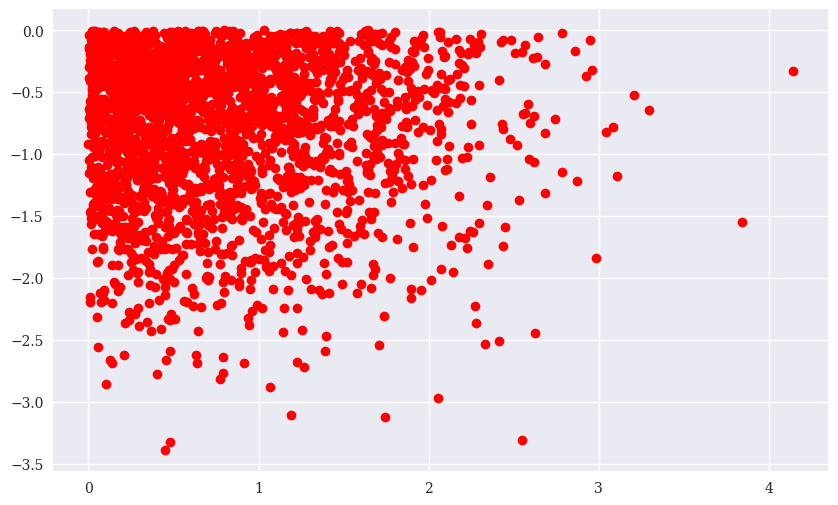

In [99]:
res = res[::100]  
plt.figure(figsize=(10, 6))
plt.plot(res[:, 0], res[:, 1], 'ro');

### From SQL to pandas
A generally more efficient approach, however, is the reading of either whole
tables or query results with pandas. When one can read a whole table into
memory, analytical queries can generally be executed much faster than when
using the disk-based approach (out-of-memory).

Reading the whole table with pandas takes roughly the same amount of time as
reading it into a NumPy ndarray object. There as here, the bottleneck
performance-wise is the database.

In [100]:
%time data = pd.read_sql('SELECT * FROM numbers', con)  

CPU times: user 1.31 s, sys: 146 ms, total: 1.46 s
Wall time: 1.53 s


In [101]:
data.head()

,No1,No2,No3,No4,No5
0,0.4918,1.3707,0.1370,0.3981,-1.0059
1,0.4516,1.4445,0.0555,-0.0397,0.4400
2,0.1629,-0.8473,-0.8223,-0.4621,-0.5137
3,1.3064,0.9125,0.5142,-0.7868,-0.3398
4,-0.1148,-1.5215,-0.7045,-1.0042,-0.0600


The data is now in-memory, which allows for much faster analytics. The
speedup is often an order of magnitude or more. pandas can also master more
complex queries, although it is neither meant nor able to replace SQL databases
when it comes to complex relational data structures. The result of the query with
multiple conditions combined is shown in Figure

In [102]:
%time data[(data['No1'] > 0) & (data['No2'] < 0)].head()  

CPU times: user 13.1 ms, sys: 1.07 ms, total: 14.2 ms
Wall time: 13.3 ms


,No1,No2,No3,No4,No5
2,0.1629,-0.8473,-0.8223,-0.4621,-0.5137
5,0.1893,-0.0207,-0.2104,0.9419,0.2551
8,1.4784,-0.3333,-0.7050,0.3586,-0.3937
10,0.8092,-0.9899,1.0364,-1.0453,0.0579
11,0.9065,-0.7757,-0.9267,0.7797,0.0863


In [103]:
%%time
q = '(No1 < -0.5 | No1 > 0.5) & (No2 < -1 | No2 > 1)'  
res = data[['No1', 'No2']].query(q)  

CPU times: user 40.1 ms, sys: 11.6 ms, total: 51.8 ms
Wall time: 37.4 ms


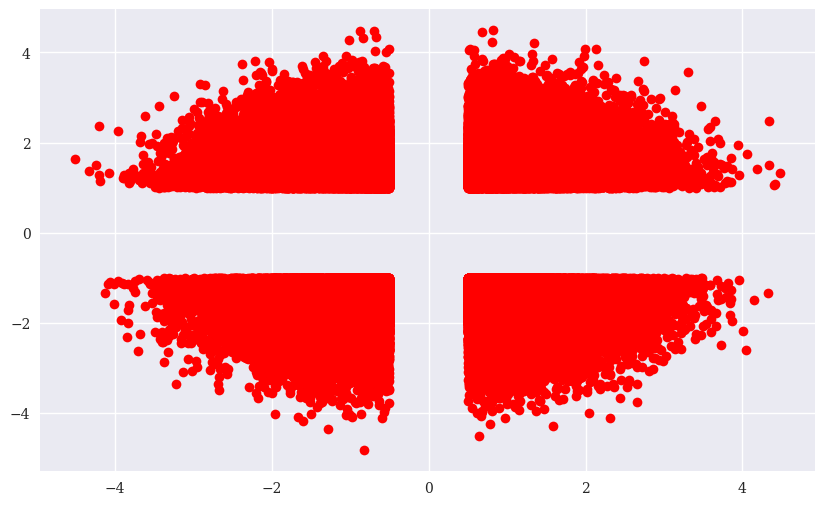

In [104]:
plt.figure(figsize=(10, 6))
plt.plot(res['No1'], res['No2'], 'ro');

As expected, using the in-memory analytics capabilities of pandas leads to a
significant speedup, provided pandas is able to replicate the respective SQL
statement.

This is not the only advantage of using pandas, since **pandas is tightly integrated
with a number of other packages (including PyTables, the topic of the
subsequent section)**.

Here, it suffices to know that the combination of both can
speed up I/O operations considerably. This is shown in the following:

In [105]:
h5s = pd.HDFStore(filename + '.h5s', 'w')

In [106]:
%time h5s['data'] = data

CPU times: user 31.9 ms, sys: 20.8 ms, total: 52.7 ms
Wall time: 54.3 ms


In [107]:
h5s  

<class 'pandas.io.pytables.HDFStore'>
File path: /root/notebook/tmp/ch09/numbers.h5s

In [108]:
h5s.close()

The whole DataFrame with all the data from the original SQL table is written
much faster when compared to the same procedure with SQLite3.

Reading is even faster:

In [109]:
%%time
h5s = pd.HDFStore(filename + '.h5s', 'r')
data_ = h5s['data']
h5s.close()

CPU times: user 27.1 ms, sys: 31.4 ms, total: 58.5 ms
Wall time: 59.8 ms


In [110]:
# The two DataFrame objects are not the same, but they now contain the same data.
data_ is data

False

In [111]:
(data_ == data).all()

No1    True
No2    True
No3    True
No4    True
No5    True
dtype: bool

In [112]:
np.allclose(data_, data)

True

Binary storage generally comes with less size overhead compared to SQL
tables, for instance:

In [113]:
ll $path*

-rw-r--r--. 1 root 52633600 Jan  6 15:39 /root/notebook/tmp/ch09/numbers.db
-rw-r--r--. 1 root 48007240 Jan  6 15:39 /root/notebook/tmp/ch09/numbers.h5s


---
### Data as CSV File
One of the most widely used formats to exchange financial data is the CSV
format. Although it is not really standardized, it can be processed by any
platform and the vast majority of applications concerned with data and financial
analytics.

Earlier, we saw how to write and read data to and from CSV files with
standard Python functionality (see “Reading and Writing Text Files”).

pandas
makes this whole procedure a bit more convenient, the code more concise, and
the execution in general faster 

In [114]:
%time data.to_csv(filename + '.csv')

CPU times: user 5.47 s, sys: 33.2 ms, total: 5.5 s
Wall time: 5.55 s


In [115]:
ll $path

total 141096
-rw-r--r--. 1 root 43834157 Jan  6 15:40 numbers.csv
-rw-r--r--. 1 root 52633600 Jan  6 15:39 numbers.db
-rw-r--r--. 1 root 48007240 Jan  6 15:39 numbers.h5s


In [116]:
%time df = pd.read_csv(filename + '.csv')

CPU times: user 470 ms, sys: 53.5 ms, total: 523 ms
Wall time: 631 ms


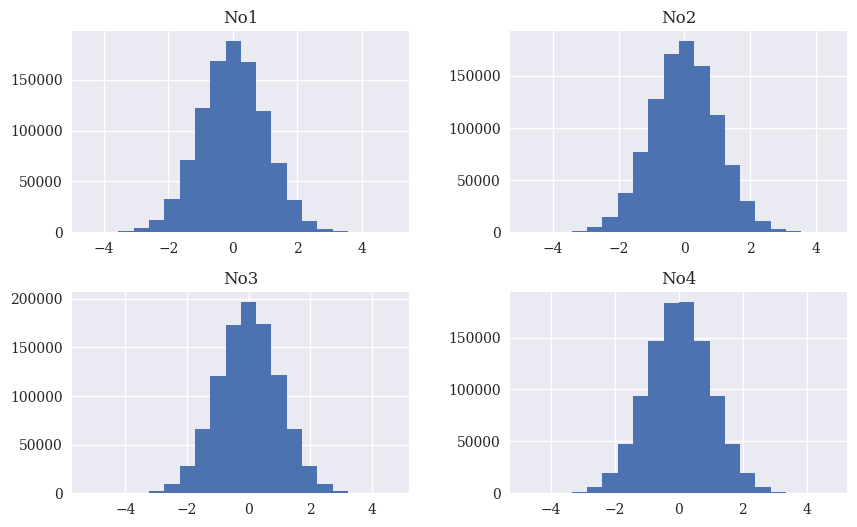

In [117]:
df[['No1', 'No2', 'No3', 'No4']].hist(bins=20, figsize=(10, 6));

---
### Data as Excel File

The following code briefly demonstrates how pandas can write data in Excel
format and read data from Excel spreadsheets. In this case, the data set is
restricted to 100,000 rows.

In [118]:
%time data[:100000].to_excel(filename + '.xlsx')

CPU times: user 15.5 s, sys: 232 ms, total: 15.7 s
Wall time: 16.1 s


In [119]:
%time df = pd.read_excel(filename + '.xlsx', 'Sheet1', index_col=0)  

CPU times: user 6.8 s, sys: 45.8 ms, total: 6.84 s
Wall time: 6.91 s


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   No1     100000 non-null  float64
 1   No2     100000 non-null  float64
 2   No3     100000 non-null  float64
 3   No4     100000 non-null  float64
 4   No5     100000 non-null  float64
dtypes: float64(5)
memory usage: 4.6 MB


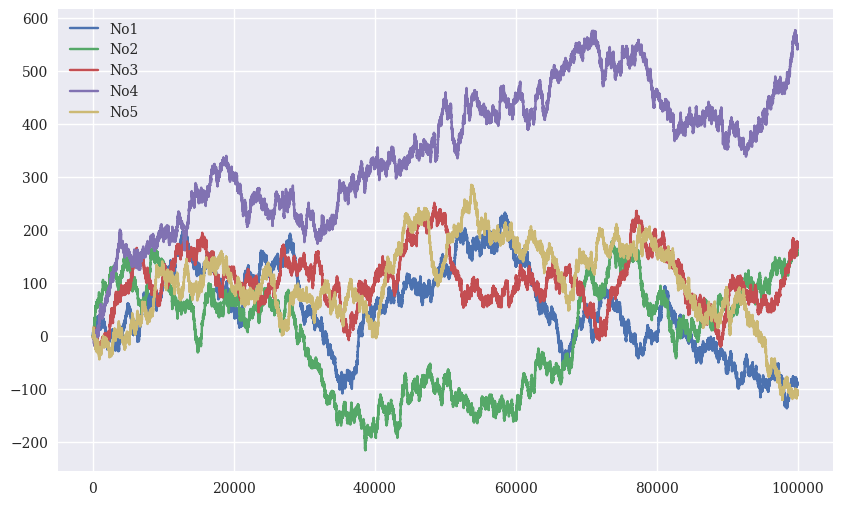

In [121]:
df.cumsum().plot(figsize=(10, 6));

In [122]:
ll $path*

-rw-r--r--. 1 root 43834157 Jan  6 15:40 /root/notebook/tmp/ch09/numbers.csv
-rw-r--r--. 1 root 52633600 Jan  6 15:39 /root/notebook/tmp/ch09/numbers.db
-rw-r--r--. 1 root 48007240 Jan  6 15:39 /root/notebook/tmp/ch09/numbers.h5s
-rw-r--r--. 1 root  4012954 Jan  6 15:40 /root/notebook/tmp/ch09/numbers.xlsx


In [123]:
rm -f $path*

Generating the Excel spreadsheet file with a smaller subset of the data takes
quite a while. This illustrates what kind of overhead the spreadsheet structure
brings along with it.

Inspection of the generated files reveals that the DataFrame with HDFStore
combination is the most compact alternative (using compression, as described in
the next section, further increases the benefits).

The same amount of data as a
CSV file — i.e., as a text file — is somewhat larger in size. This is one reason
for the slower performance when working with CSV files, the other being the
very fact that they are “only” general text files.

---
## Fast I/O with PyTables

**PyTables is a Python binding for the HDF5 database standard**. It is specifically
designed to optimize the performance of I/O operations and make best use of the
available hardware.

The library’s import name is tables. Similar to pandas,
when it comes to in-memory analytics PyTables is neither able nor meant to be a
full replacement for SQL databases. However, it brings along some features that
further close the gap. For example, a PyTables database can have many tables,
and it supports compression and indexing and also nontrivial queries on tables.
In addition, it can store NumPy arrays efficiently and has its own flavor of array-
like data structures.

In [124]:
import tables as tb  
import datetime as dt

### Working with Tables

PyTables provides a file-based database format, similar to SQLite3.5 The
following opens a database file and creates a table:

In [125]:
filename = path + 'pytab.h5'

In [126]:
h5 = tb.open_file(filename, 'w')

In [127]:
row_des = {
    'Date': tb.StringCol(26, pos=1),
    'No1': tb.IntCol(pos=2),
    'No2': tb.IntCol(pos=3),
    'No3': tb.Float64Col(pos=4),
    'No4': tb.Float64Col(pos=5)
    }

In [128]:
rows = 2000000

In [129]:
filters = tb.Filters(complevel=0)

In [130]:
tab = h5.create_table('/', 'ints_floats',
                      row_des,
                      title='Integers and Floats',
                      expectedrows=rows,
                      filters=filters)

In [131]:
type(tab)

tables.table.Table

In [132]:
tab

/ints_floats (Table(np.int64(0),)) np.str_('Integers and Floats')
  description := {
  "Date": StringCol(itemsize=26, shape=(), dflt=np.bytes_(b''), pos=0),
  "No1": Int32Col(shape=(), dflt=np.int32(0), pos=1),
  "No2": Int32Col(shape=(), dflt=np.int32(0), pos=2),
  "No3": Float64Col(shape=(), dflt=np.float64(0.0), pos=3),
  "No4": Float64Col(shape=(), dflt=np.float64(0.0), pos=4)}
  byteorder := 'little'
  chunkshape := (np.int64(2621),)

To populate the table with numerical data, two ndarray objects with random
numbers are generated: one with random integers, the other with random
floating-point numbers. The population of the table happens via a simple Python
loop:

In [133]:
pointer = tab.row

In [134]:
ran_int = np.random.randint(0, 10000, size=(rows, 2))

In [135]:
ran_flo = np.random.standard_normal((rows, 2)).round(4)

In [136]:
%%time
for i in range(rows):
    pointer['Date'] = dt.datetime.now()  
    pointer['No1'] = ran_int[i, 0]  
    pointer['No2'] = ran_int[i, 1]  
    pointer['No3'] = ran_flo[i, 0]  
    pointer['No4'] = ran_flo[i, 1]  
    pointer.append()  
tab.flush()  

CPU times: user 6.45 s, sys: 38.5 ms, total: 6.48 s
Wall time: 6.52 s


In [137]:
tab

/ints_floats (Table(np.int64(2000000),)) np.str_('Integers and Floats')
  description := {
  "Date": StringCol(itemsize=26, shape=(), dflt=np.bytes_(b''), pos=0),
  "No1": Int32Col(shape=(), dflt=np.int32(0), pos=1),
  "No2": Int32Col(shape=(), dflt=np.int32(0), pos=2),
  "No3": Float64Col(shape=(), dflt=np.float64(0.0), pos=3),
  "No4": Float64Col(shape=(), dflt=np.float64(0.0), pos=4)}
  byteorder := 'little'
  chunkshape := (np.int64(2621),)

In [138]:
ll $path*

-rw-r--r--. 1 root 100156248 Jan  6 15:40 /root/notebook/tmp/ch09/pytab.h5


The Python loop is quite slow in this case. There is a more performant and
Pythonic way to accomplish the same result, by the use of NumPy structured
arrays.

Equipped with the complete data set stored in a structured array, the
creation of the table boils down to a single line of code.

Note that the row
description is not needed anymore; PyTables uses the dtype object of the
structured array to infer the data types instead:

In [139]:
dty = np.dtype([('Date', 'S26'), ('No1', '<i4'), ('No2', '<i4'),
                                 ('No3', '<f8'), ('No4', '<f8')])  

In [140]:
sarray = np.zeros(len(ran_int), dtype=dty)  

In [141]:
sarray[:4]  

array([(b'', 0, 0, 0., 0.), (b'', 0, 0, 0., 0.), (b'', 0, 0, 0., 0.),
       (b'', 0, 0, 0., 0.)],
      dtype=[('Date', 'S26'), ('No1', '<i4'), ('No2', '<i4'), ('No3', '<f8'), ('No4', '<f8')])

In [142]:
%%time
sarray['Date'] = dt.datetime.now()  
sarray['No1'] = ran_int[:, 0]  
sarray['No2'] = ran_int[:, 1]  
sarray['No3'] = ran_flo[:, 0]  
sarray['No4'] = ran_flo[:, 1]  

CPU times: user 77.8 ms, sys: 86.7 ms, total: 165 ms
Wall time: 168 ms


In [143]:
%%time
h5.create_table('/', 'ints_floats_from_array', sarray,
                      title='Integers and Floats',
                      expectedrows=rows, filters=filters)  

CPU times: user 23.7 ms, sys: 174 ms, total: 198 ms
Wall time: 202 ms


/ints_floats_from_array (Table(np.int64(2000000),)) np.str_('Integers and Floats')
  description := {
  "Date": StringCol(itemsize=26, shape=(), dflt=np.bytes_(b''), pos=0),
  "No1": Int32Col(shape=(), dflt=np.int32(0), pos=1),
  "No2": Int32Col(shape=(), dflt=np.int32(0), pos=2),
  "No3": Float64Col(shape=(), dflt=np.float64(0.0), pos=3),
  "No4": Float64Col(shape=(), dflt=np.float64(0.0), pos=4)}
  byteorder := 'little'
  chunkshape := (np.int64(2621),)

This approach is an order of magnitude faster, has more concise code, and
achieves the same result:

In [144]:
type(h5)

tables.file.File

In [145]:
h5

File(filename=/root/notebook/tmp/ch09/pytab.h5, title=np.str_(''), mode='w', root_uep='/', filters=Filters(complevel=0, shuffle=False, bitshuffle=False, fletcher32=False, least_significant_digit=None))
/ (RootGroup) np.str_('')
/ints_floats (Table(np.int64(2000000),)) np.str_('Integers and Floats')
  description := {
  "Date": StringCol(itemsize=26, shape=(), dflt=np.bytes_(b''), pos=0),
  "No1": Int32Col(shape=(), dflt=np.int32(0), pos=1),
  "No2": Int32Col(shape=(), dflt=np.int32(0), pos=2),
  "No3": Float64Col(shape=(), dflt=np.float64(0.0), pos=3),
  "No4": Float64Col(shape=(), dflt=np.float64(0.0), pos=4)}
  byteorder := 'little'
  chunkshape := (np.int64(2621),)
/ints_floats_from_array (Table(np.int64(2000000),)) np.str_('Integers and Floats')
  description := {
  "Date": StringCol(itemsize=26, shape=(), dflt=np.bytes_(b''), pos=0),
  "No1": Int32Col(shape=(), dflt=np.int32(0), pos=1),
  "No2": Int32Col(shape=(), dflt=np.int32(0), pos=2),
  "No3": Float64Col(shape=(), dflt=np.flo

In [146]:
h5.remove_node('/', 'ints_floats_from_array')

The Table object behaves pretty similar to NumPy structured ndarray objects in
most cases

In [147]:
tab[:3]

array([(b'2026-01-06 15:40:29.266280', 8576, 5991, -0.0528, 0.2468),
       (b'2026-01-06 15:40:29.266323', 2990, 9310, -0.0261, 0.3932),
       (b'2026-01-06 15:40:29.266327', 4400, 4823,  0.9133, 0.2579)],
      dtype=[('Date', 'S26'), ('No1', '<i4'), ('No2', '<i4'), ('No3', '<f8'), ('No4', '<f8')])

In [148]:
tab[:4]['No4']

array([ 0.2468,  0.3932,  0.2579, -0.5582])

In [149]:
%time np.sum(tab[:]['No3'])

CPU times: user 20.2 ms, sys: 124 ms, total: 144 ms
Wall time: 147 ms


np.float64(88.8542999999997)

In [150]:
%time np.sum(np.sqrt(tab[:]['No1']))

CPU times: user 23.2 ms, sys: 47.6 ms, total: 70.7 ms
Wall time: 70 ms


np.float64(133349920.3689251)

CPU times: user 106 ms, sys: 30.7 ms, total: 137 ms
Wall time: 137 ms


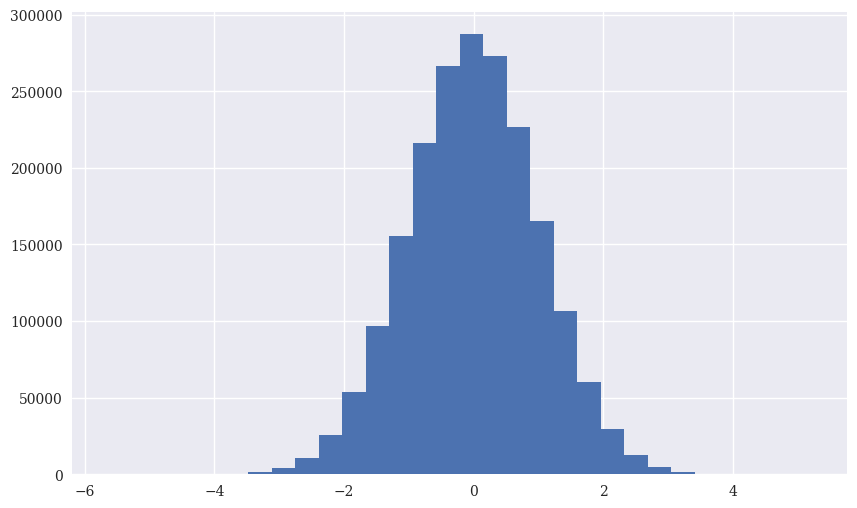

In [151]:
%%time
plt.figure(figsize=(10, 6))
plt.hist(tab[:]['No3'], bins=30);

PyTables also provides flexible tools to query data via typical SQL-like
statements, as in the following example

In [152]:
query = '((No3 < -0.5) | (No3 > 0.5)) & ((No4 < -1) | (No4 > 1))'

In [153]:
iterator = tab.where(query)

In [154]:
%time res = [(row['No3'], row['No4']) for row in iterator]

CPU times: user 170 ms, sys: 39.9 ms, total: 210 ms
Wall time: 168 ms


In [155]:
res = np.array(res)
res[:3]

array([[0.7694, 1.4866],
       [0.9201, 1.3346],
       [1.4701, 1.8776]])

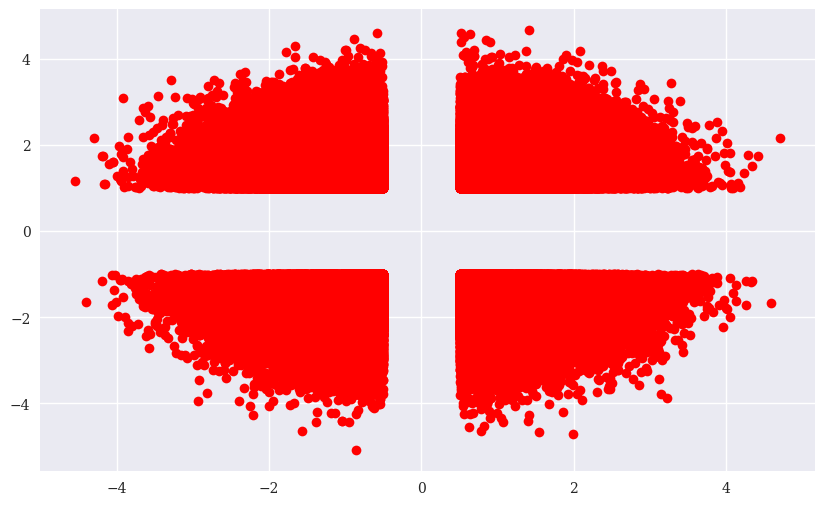

In [156]:
plt.figure(figsize=(10, 6))
plt.plot(res.T[0], res.T[1], 'ro');

#### FAST QUERIES
Both pandas and PyTables are able to process relatively complex, SQL-like queries and
selections. They are both optimized for speed when it comes to such operations.

Although
there are limits to these approaches compared to relational databases, for most numerical and
financial applications these are often not relevant.

As the following examples show, working with data stored in PyTables as Table
objects gives the impression of working with NumPy or pandas objects in-
memory, both from a syntax and a performance point of view

In [157]:
%%time
values = tab[:]['No3']
print('Max %18.3f' % values.max())
print('Ave %18.3f' % values.mean())
print('Min %18.3f' % values.min())
print('Std %18.3f' % values.std())

Max              5.224
Ave              0.000
Min             -5.649
Std              1.000
CPU times: user 58.5 ms, sys: 71.9 ms, total: 130 ms
Wall time: 130 ms


In [158]:
%%time
res = [(row['No1'], row['No2']) for row in
        tab.where('((No1 > 9800) | (No1 < 200)) \
                & ((No2 > 4500) & (No2 < 5500))')]

CPU times: user 67.9 ms, sys: 21.5 ms, total: 89.3 ms
Wall time: 51.2 ms


In [159]:
for r in res[:4]:
    print(r)

(91, 4870)
(9803, 5026)
(9846, 4859)
(9823, 5069)


In [160]:
%%time
res = [(row['No1'], row['No2']) for row in
        tab.where('(No1 == 1234) & (No2 > 9776)')]

CPU times: user 55.2 ms, sys: 15.8 ms, total: 71 ms
Wall time: 44.5 ms


In [161]:
for r in res:
    print(r)

(1234, 9841)
(1234, 9821)
(1234, 9867)
(1234, 9987)
(1234, 9849)
(1234, 9800)


---
### Working with Compressed Tables

A major advantage of working with PyTables is the approach it takes to
compression. It uses compression not only to save space on disk, but also to
improve the performance of I/O operations in certain hardware scenarios.

How
does this work? When I/O is the bottleneck and the CPU is able to (de)compress
data fast, the net effect of compression in terms of speed might be positive.

Since
the following examples are based on the I/O of a standard SSD, there is no speed
advantage of compression to be observed. However, there is also almost no
disadvantage to using compression:

In [162]:
filename = path + 'pytabc.h5'

In [163]:
h5c = tb.open_file(filename, 'w') 

In [164]:
filters = tb.Filters(complevel=5,  
                     complib='blosc')  

In [165]:
tabc = h5c.create_table('/', 'ints_floats', sarray,
                        title='Integers and Floats',
                        expectedrows=rows, filters=filters)

In [166]:
query = '((No3 < -0.5) | (No3 > 0.5)) & ((No4 < -1) | (No4 > 1))'

In [167]:
iteratorc = tabc.where(query)

In [168]:
%time res = [(row['No3'], row['No4']) for row in iteratorc]

CPU times: user 211 ms, sys: 34 ms, total: 245 ms
Wall time: 227 ms


In [169]:
res = np.array(res)
res[:3]

array([[0.7694, 1.4866],
       [0.9201, 1.3346],
       [1.4701, 1.8776]])

Generating the compressed Table object with the original data and doing
analytics on it is slightly slower compared to the uncompressed Table object.

What about reading the data into an ndarray object? Let’s check:

In [170]:
%time arr_non = tab.read()

CPU times: user 17 ms, sys: 123 ms, total: 140 ms
Wall time: 142 ms


In [171]:
tab.size_on_disk

100122200

In [172]:
arr_non.nbytes

100000000

In [173]:
%time arr_com = tabc.read()

CPU times: user 28 ms, sys: 215 ms, total: 243 ms
Wall time: 244 ms


In [174]:
tabc.size_on_disk

99995415

In [175]:
arr_com.nbytes

100000000

In [176]:
ll $path*  

-rw-r--r--. 1 root 200312336 Jan  6 15:40 /root/notebook/tmp/ch09/pytab.h5
-rw-r--r--. 1 root 100030711 Jan  6 15:40 /root/notebook/tmp/ch09/pytabc.h5


In [177]:
h5c.close()  

The examples show that there is hardly any speed difference when working with
compressed Table objects as compared to uncompressed ones.

However, file
sizes on disk might — depending on the quality of the data — be significantly
reduced, which has a number of benefits.

---
### Working with Arrays

“Basic I/O with Python” showed that NumPy has built-in fast writing and reading
capabilities for ndarray objects. PyTables is also quite fast and efficient when it
comes to storing and retrieving ndarray objects, and since it is based on a
hierarchical database structure, many convenience features come on top:

In [178]:
%%time
arr_int = h5.create_array('/', 'integers', ran_int)
arr_flo = h5.create_array('/', 'floats', ran_flo)

CPU times: user 3.56 ms, sys: 69.5 ms, total: 73 ms
Wall time: 75.3 ms


In [179]:
h5

File(filename=/root/notebook/tmp/ch09/pytab.h5, title=np.str_(''), mode='w', root_uep='/', filters=Filters(complevel=0, shuffle=False, bitshuffle=False, fletcher32=False, least_significant_digit=None))
/ (RootGroup) np.str_('')
/floats (Array(2000000, 2)) np.str_('')
  atom := Float64Atom(shape=(), dflt=np.float64(0.0))
  maindim := 0
  flavor := 'numpy'
  byteorder := 'little'
  chunkshape := None
/integers (Array(2000000, 2)) np.str_('')
  atom := Int64Atom(shape=(), dflt=np.int64(0))
  maindim := 0
  flavor := 'numpy'
  byteorder := 'little'
  chunkshape := None
/ints_floats (Table(np.int64(2000000),)) np.str_('Integers and Floats')
  description := {
  "Date": StringCol(itemsize=26, shape=(), dflt=np.bytes_(b''), pos=0),
  "No1": Int32Col(shape=(), dflt=np.int32(0), pos=1),
  "No2": Int32Col(shape=(), dflt=np.int32(0), pos=2),
  "No3": Float64Col(shape=(), dflt=np.float64(0.0), pos=3),
  "No4": Float64Col(shape=(), dflt=np.float64(0.0), pos=4)}
  byteorder := 'little'
  chunkshape 

In [180]:
ll $path*

-rw-r--r--. 1 root 262344490 Jan  6 15:40 /root/notebook/tmp/ch09/pytab.h5
-rw-r--r--. 1 root 100030711 Jan  6 15:40 /root/notebook/tmp/ch09/pytabc.h5


In [181]:
h5.close()

In [182]:
!rm -f $path*

Writing these objects directly to an HDF5 database is faster than looping over
the objects and writing the data row-by-row to a Table object or using the
approach via structured ndarray objects.

#### HDF5-BASED DATA STORAGE
The HDF5 hierarchical database (file) format is a powerful alternative to, for example,
relational databases when it comes to structured numerical and financial data.

Both on a
standalone basis when using PyTables directly and when combining it with the capabilities of
pandas, one can expect to get almost the maximum I/O performance that the available
hardware allows.

---
### Out-of-Memory Computations

PyTables supports out-of-memory operations, which makes it possible to
implement array-based computations that do not fit in memory.

To this end,
consider the following code based on the EArray class. This type of object can
be expanded in one dimension (row-wise), while the number of columns
(elements per row) needs to be fixed:

In [183]:
filename = path + 'earray.h5'

In [184]:
h5 = tb.open_file(filename, 'w')

In [185]:
n = 500

In [186]:
ear = h5.create_earray('/', 'ear',
                      atom=tb.Float64Atom(),
                      shape=(0, n))

In [187]:
type(ear)

tables.earray.EArray

In [188]:
rand = np.random.standard_normal((n, n))
rand[:4, :4]

array([[-1.25983231,  1.11420699,  0.1667485 ,  0.7345676 ],
       [-0.13785424,  1.22232417,  1.36303097,  0.13521042],
       [ 1.45487119, -1.47784078,  0.15027672,  0.86755989],
       [-0.63519366,  0.1516327 , -0.64939447, -0.45010975]])

In [189]:
%%time
for _ in range(750):
    ear.append(rand)
ear.flush()

CPU times: user 480 ms, sys: 2.25 s, total: 2.73 s
Wall time: 4.64 s


In [190]:
ear

/ear (EArray(np.int64(375000), np.int64(500))) ''
  atom := Float64Atom(shape=(), dflt=np.float64(0.0))
  maindim := 0
  flavor := 'numpy'
  byteorder := 'little'
  chunkshape := (np.int64(16), np.int64(500))

In [191]:
# display size in GiB
ear.size_on_disk / (1024 ** 3)

1.3970136642456055

For out-of-memory computations that do not lead to aggregations, another
EArray object of the same shape (size) is needed.

PyTables has a special module
to cope with numerical expressions efficiently. It is called Expr and is based on
the numerical expression library numexpr.

The code that follows uses Expr to
calculate the mathematical expression in Equation 9-1 on the whole EArray
object from before.

The results are stored in the out EArray object, and the expression evaluation
happens chunk-wise:

In [192]:
out = h5.create_earray('/', 'out',
                      atom=tb.Float64Atom(),
                      shape=(0, n))

In [193]:
out.size_on_disk

0

In [194]:
expr = tb.Expr('3 * sin(ear) + sqrt(abs(ear))')

In [195]:
expr.set_output(out, append_mode=True)

In [196]:
%time expr.eval()

CPU times: user 8.15 s, sys: 6.41 s, total: 14.6 s
Wall time: 15.4 s


/out (EArray(np.int64(375000), np.int64(500))) ''
  atom := Float64Atom(shape=(), dflt=np.float64(0.0))
  maindim := 0
  flavor := 'numpy'
  byteorder := 'little'
  chunkshape := (np.int64(16), np.int64(500))

In [197]:
# display size in GiB
out.size_on_disk / (1024 ** 3)

1.3970136642456055

In [198]:
out[0, :10]

array([-1.73369462,  3.74824436,  0.90627898,  2.86786818,  1.75424957,
       -0.91108973, -1.68313885,  1.29073295, -1.68665599, -1.71345309])

In [199]:
%time out_ = out.read()

CPU times: user 395 ms, sys: 1.55 s, total: 1.95 s
Wall time: 10.5 s


In [200]:
out_[0, :10]

array([-1.73369462,  3.74824436,  0.90627898,  2.86786818,  1.75424957,
       -0.91108973, -1.68313885,  1.29073295, -1.68665599, -1.71345309])

Given that the whole operation takes place out-of-memory, it can be considered
quite fast, in particular as it is executed on standard hardware.

As a benchmark,
the in-memory performance of the numexpr module (see also Chapter 10) can be
considered. It is faster, but not by a huge margin:

In [201]:
import numexpr as ne

In [202]:
expr = '3 * sin(out_) + sqrt(abs(out_))'

In [203]:
ne.set_num_threads(1)

8

In [204]:
%time ne.evaluate(expr)[0, :10]

CPU times: user 6.46 s, sys: 3.08 s, total: 9.54 s
Wall time: 36.3 s


array([-1.64358578,  0.22567882,  3.31363043,  2.50443549,  4.27413965,
       -1.41600606, -1.68373023,  4.01921805, -1.68117412, -1.66053597])

In [205]:
ne.set_num_threads(4)

1

In [206]:
%time ne.evaluate(expr)[0, :10]

CPU times: user 9.97 s, sys: 7.51 s, total: 17.5 s
Wall time: 1min 24s


array([-1.64358578,  0.22567882,  3.31363043,  2.50443549,  4.27413965,
       -1.41600606, -1.68373023,  4.01921805, -1.68117412, -1.66053597])

In [207]:
h5.close()

In [208]:
!rm -f $path*

---
## TsTables
The package TsTables uses PyTables to build a high-performance storage for
time series data. The major usage scenario is **"write once, retrieve multiple
times."**

This is a typical scenario in financial analytics, where data is created in
the markets, retrieved in real-time or asynchronously, and stored on disk for later
usage. That usage might be in a larger trading strategy backtesting program that
requires different subsets of a historical financial time series over and over
again.

It is then important that data retrieval happens fast.

### Sample Data
As usual, the first task is the generation of a sample data set that is large enough
to illustrate the benefits of TsTables. The following code generates three rather
long financial time series based on the simulation of a geometric Brownian
motion (see Chapter 12):

In [209]:
# number of steps
no = 5000000
# number of time series
co = 3
# time interval as a year fraction
interval = 1. / (12 * 30 * 24 * 60)
# volatility
vol = 0.2

In [210]:
%%time
rn = np.random.standard_normal((no, co))
rn[0] = 0.0
start_val = 100
paths = start_val * np.exp(np.cumsum(-0.5 * vol ** 2 * interval +
                    vol * np.sqrt(interval) * rn, axis=0))
paths[0] = start_val

CPU times: user 898 ms, sys: 788 ms, total: 1.69 s
Wall time: 5.44 s


In [211]:
# Since TsTables works pretty well with pandas DataFrame objects, data is transformed
dr = pd.date_range('2019-1-1', periods=no, freq='1s')

In [212]:
dr[-6:]

DatetimeIndex(['2019-02-27 20:53:14', '2019-02-27 20:53:15',
               '2019-02-27 20:53:16', '2019-02-27 20:53:17',
               '2019-02-27 20:53:18', '2019-02-27 20:53:19'],
              dtype='datetime64[ns]', freq='s')

In [213]:
df = pd.DataFrame(paths, index=dr, columns=['ts1', 'ts2', 'ts3'])

In [214]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5000000 entries, 2019-01-01 00:00:00 to 2019-02-27 20:53:19
Freq: s
Data columns (total 3 columns):
 #   Column  Dtype  
---  ------  -----  
 0   ts1     float64
 1   ts2     float64
 2   ts3     float64
dtypes: float64(3)
memory usage: 152.6 MB


In [215]:
df.head()

,ts1,ts2,ts3
2019-01-01 00:00:00,100.000000,100.000000,100.000000
2019-01-01 00:00:01,100.018443,99.966644,99.998255
2019-01-01 00:00:02,100.069023,100.004420,99.986646
2019-01-01 00:00:03,100.086757,100.000246,99.992042
2019-01-01 00:00:04,100.105448,100.036033,99.950618


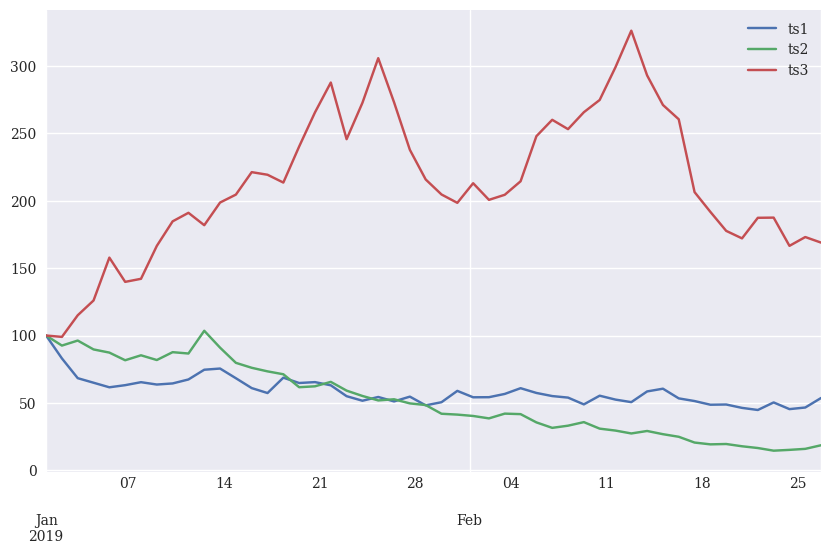

In [216]:
df[::100000].plot(figsize=(10, 6));
# plt.savefig('../../images/ch09/io_07.png')

### Data Storage (with `tstables`)

A friendly fork for TsTables is found at http://github.com/yhilpisch/tstables, which is maintained for compatibility with newer
versions of pandas and other Python packages.

<b style="color: red;">Install the package as follows:</b>

    pip install git+https://github.com/yhilpisch/tstables

TsTables stores financial time series data based on a specific chunk-based
structure that allows for fast retrieval of arbitrary data subsets defined by some
time interval. To this end, the package adds the function create_ts() to
PyTables. To provide the data types for the table columns, the following uses a
method based on the tb.IsDe⁠scription class from PyTables:

In [217]:
import tstables as tstab

In [218]:
class ts_desc(tb.IsDescription):
    timestamp = tb.Int64Col(pos=0)  
    ts1 = tb.Float64Col(pos=1)  
    ts2 = tb.Float64Col(pos=2)  
    ts3 = tb.Float64Col(pos=3)  

In [219]:
h5 = tb.open_file(path + 'tstab.h5', 'w')

In [220]:
ts = h5.create_ts('/', 'ts', ts_desc)

In [221]:
%time ts.append(df)

CPU times: user 618 ms, sys: 1.02 s, total: 1.64 s
Wall time: 2.38 s


In [222]:
type(ts)

tstables.tstable.TsTable

In [223]:
ls -n $path

total 126808
-rw-r--r--. 1 0 0 129850400 Jan  6 15:43 tstab.h5


#### Data Retrieval

Writing data with TsTables obviously is quite fast, even if hardware-dependent.
The same holds true for reading chunks of the data back into memory.

Conveniently, TsTables returns a DataFrame object:

In [224]:
read_start_dt = dt.datetime(2019, 2, 1, 0, 0)
read_end_dt = dt.datetime(2019, 2, 5, 23, 59)  #<2>

In [225]:
%time rows = ts.read_range(read_start_dt, read_end_dt)

CPU times: user 67.7 ms, sys: 70.5 ms, total: 138 ms
Wall time: 443 ms


In [226]:
rows.info()  

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 431941 entries, 2019-02-01 00:00:00 to 2019-02-05 23:59:00
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ts1     431941 non-null  float64
 1   ts2     431941 non-null  float64
 2   ts3     431941 non-null  float64
dtypes: float64(3)
memory usage: 13.2 MB


In [227]:
rows.head()  

,ts1,ts2,ts3
2019-02-01 00:00:00,52.063640,40.474580,217.324713
2019-02-01 00:00:01,52.087455,40.471911,217.250070
2019-02-01 00:00:02,52.084808,40.458013,217.228712
2019-02-01 00:00:03,52.073536,40.451408,217.302912
2019-02-01 00:00:04,52.056133,40.450951,217.207481


In [228]:
h5.close()

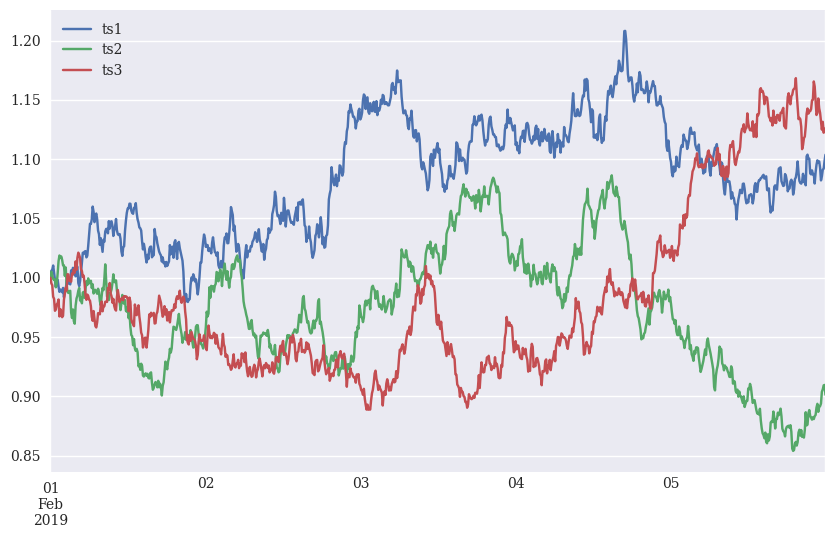

In [229]:
# A specific time interval of the financial time series (normalized)
(rows[::500] / rows.iloc[0]).plot(figsize=(10, 6));

To better illustrate the performance of the TsTables-based data retrieval,
consider the following benchmark, which retrieves 100 chunks of data consisting
of 3 days’ worth of 1-second bars.

The retrieval of a DataFrame with 345,600
rows of data takes less than one-tenth of a second:

In [230]:
import random

In [231]:
h5 = tb.open_file(path + 'tstab.h5', 'r')

In [232]:
ts = h5.root.ts._f_get_timeseries()  

In [233]:
%%time
for _ in range(100):  
    d = random.randint(1, 24)  
    read_start_dt = dt.datetime(2019, 2, d, 0, 0, 0)
    read_end_dt = dt.datetime(2019, 2, d + 3, 23, 59, 59)
    rows = ts.read_range(read_start_dt, read_end_dt)

CPU times: user 2.99 s, sys: 139 ms, total: 3.13 s
Wall time: 3.48 s


In [234]:
rows.info()  

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 345600 entries, 2019-02-08 00:00:00 to 2019-02-11 23:59:59
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ts1     345600 non-null  float64
 1   ts2     345600 non-null  float64
 2   ts3     345600 non-null  float64
dtypes: float64(3)
memory usage: 10.5 MB


In [235]:
!rm $path/tstab.h5

# Conclusion
SQL-based or relational databases have advantages when it comes to complex
data structures that exhibit lots of relations between single objects/tables. This
might justify in some circumstances their performance disadvantage over pure
NumPy ndarray-based or pandas DataFrame–based approaches.

Many application areas in finance or science in general can succeed with a
mainly array-based data modeling approach. In these cases, huge performance
improvements can be realized by making use of native NumPy I/O capabilities, a
combination of NumPy and PyTables capabilities, or the pandas approach via
HDF5-based stores. TsTables is particularly useful when working with large
(financial) time series data sets, especially in “write once, retrieve multiple
times” scenarios.

While a recent trend has been to use cloud-based solutions — where the cloud is
made up of a large number of computing nodes based on commodity hardware
— one should carefully consider, especially in a financial context, which
hardware architecture best serves the analytics requirements. A study by
Microsoft sheds some light on this topic:

We claim that a single “scale-up” server can process each of these jobs and do
as well or better than a cluster in terms of performance, cost, power, and
server density.
Appuswamy et al. (2013)
Companies, research institutions, and others involved in data analytics should
therefore analyze first what specific tasks have to be accomplished in general
and then decide on the hardware/software architecture, in terms of:

###### Scaling out
Using a cluster with many commodity nodes with standard CPUs and
relatively low memory

###### Scaling up
Using one or a few powerful servers with many-core CPUs, possibly also
GPUs or even TPUs when machine and deep learning play a role, and large
amounts of memory

Scaling up hardware and applying appropriate implementation approaches might
significantly influence performance, which is the focus of the next chapter.

<img src="https://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

<a href="https://tpq.io" target="_blank">https://tpq.io</a> | <a href="https://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:training@tpq.io">training@tpq.io</a>